# GeoCarb instrument-design sweep with GERT

How do **GSD** and **dwell time** propagate into the posterior uncertainty on
retrieved **XCO₂**?

The seam:

```
geosat_geometry   (mission: orbit, slit, scan, per-pixel geometry)
   └─ geocarb_gert (adapter + mission-side GSD/dwell → noise model)
        └─ gert    (radiance, Jacobian, posterior)
```

**GeoCarb stares from GEO**, so integration time is *independent of GSD* —
unlike a LEO pushbroom (`t_int = GSD/v_ground`). That coupling is a property of
how the mission flies, so it lives here, not in the library.

In [1]:
import sys, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

GERT_ROOT = Path("../../../gert").resolve()  # notebooks/ -> geocarb_simulator -> research -> My Drive

import geosat_geometry as gg
from geocarb_gert import (build_geocarb_instrument, base_noise_model,
                          staring_sweep_models, sample_geometries, gsd_km,
                          scene_from_profile, reference_atmosphere, GEOCARB_REF)
import gert
from gert.osse import simulate, StateSpec, run_design_sweep
from gert.rt_solver import VectorDOSolver
from gert.radiometry import DetectorSpec
print("gert", gert.__version__, "| absco:", (GERT_ROOT/'input/absco/absco.h5').exists())

gert 0.1.0 | absco: True


## 1. Mission — a real ScanBlock pixel

The simulator already supplies solar/viewing angles per pixel.

In [2]:
sat   = gg.LongSlitGeoSatellite(sat_lon_deg=-85.0)
block = gg.geocarb_demo(verbose=False)["blocks"][0]
row, col, geo = sample_geometries(block, n=1, seed=0)[0]
print(f"ScanBlock {block.shape}  pixel (row={row}, col={col})")
print(f"GSD={gsd_km(sat):.1f} km   t_int={sat.integration_time_s:.0f} s  (staring)")
print(f"SZA={geo.sza:.2f}  VZA={geo.vza:.2f}  RAA={geo.raa:.2f}")

ScanBlock (500, 402)  pixel (row=425, col=125)
GSD=6.0 km   t_int=10 s  (staring)
SZA=31.89  VZA=54.68  RAA=29.88


## 2. Instrument + scene

Four GeoCarb bands; the mission supplies its own atmosphere (GERT never owns one).

In [3]:
instrument = build_geocarb_instrument()
n_bands = len(instrument.windows)
atm   = reference_atmosphere()
absco = gert.ABSCOTable.load_all(str(GERT_ROOT/'input/absco/absco.h5'))
solar = gert.SolarSpectrum.load(str(GERT_ROOT/'input/solar/solar.h5'))
scene = scene_from_profile(atm, albedo=np.full(n_bands, 0.25))
print("bands:", [w.label for w in instrument.windows],
      "| channels:", sum(w.n_channels for w in instrument.windows))

bands: ['O2_A', 'CO2_weak', 'CO2_strong', 'CH4_CO'] | channels: 4206


In [4]:
obs = simulate(scene, instrument, geo, absco=absco, solar_spectrum=solar,
               solver=VectorDOSolver(), snr=300., add_noise=True, seed=0)
print("truth radiance:", obs.y_truth.size, "channels")

truth radiance: 4206 channels


## 3. Mission-side noise models over (GSD × dwell)

A quoted SNR cannot separate étendue, throughput and QE, so we calibrate a
*lumped* throughput from the spec point and rescale it. For a staring
instrument étendue ∝ GSD² at fixed optics, and dwell is passed through freely.

In [5]:
w        = instrument.windows[1]                     # CO2_weak
wl_ref   = float(np.mean(w.wl_instrument))
dlam_ref = float(np.mean(np.abs(np.gradient(w.wl_instrument))))
R_ref    = float(np.max(np.abs(obs.R_band[1])))
det  = DetectorSpec(read_noise_e=30., dark_current_e_s=1e3, full_well_e=1e6, bit_depth=14)
base = base_noise_model(300., R_ref, wl_ref, dlam_ref,
                        t_int_s=GEOCARB_REF['t_int_s'], detector=det)

gsds   = [3., 6., 12.]      # km
dwells = [2.5, 10., 40.]    # s
models = staring_sweep_models(base, gsds, dwells)
print(len(models), "design points")

9 design points


## 4. The sweep — one Jacobian for the whole grid

`S_ret = (KᵀSy⁻¹K + Sa⁻¹)⁻¹` does not depend on the noise *realization*, and
GSD/dwell only rescale `Sy`. So `K` is computed **once**; each design point is
then pure linear algebra.

In [6]:
spec = StateSpec(label='gas+albedo', gases=('co2','ch4','h2o'))
pts  = run_design_sweep(obs, atm, spec, models, solver_kind='ms', verbose=False)
by   = {p.label: p for p in pts}

sig = np.array([[by[f'{g:g} km / {t:g} s'].xco2_uncert_ppm for t in dwells] for g in gsds])
sat = np.array([[by[f'{g:g} km / {t:g} s'].saturated_frac  for t in dwells] for g in gsds])
dof = np.array([[by[f'{g:g} km / {t:g} s'].dof             for t in dwells] for g in gsds])
import pandas as pd
print("sigma(XCO2) [ppm]"); print(pd.DataFrame(sig, index=[f'{g:g} km' for g in gsds],
                                               columns=[f'{t:g} s' for t in dwells]).round(3))
print("\nsaturated fraction"); print(pd.DataFrame(sat, index=[f'{g:g} km' for g in gsds],
                                               columns=[f'{t:g} s' for t in dwells]))

sigma(XCO2) [ppm]
       2.5 s   10 s   40 s
3 km   2.213  1.022  0.499
6 km   0.800  0.382  0.189
12 km  0.338  0.166  0.082

saturated fraction
       2.5 s  10 s      40 s
3 km     0.0   0.0  0.000000
6 km     0.0   0.0  0.000000
12 km    0.0   0.0  0.567047


### σ(XCO₂) map — saturated (physically invalid) points hatched

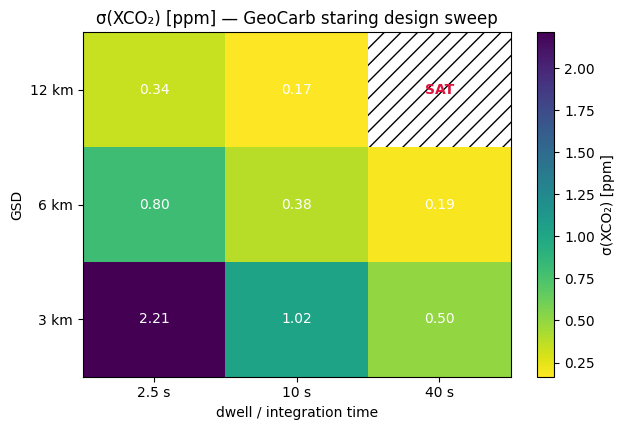

In [7]:
fig, ax = plt.subplots(figsize=(6.4,4.4))
masked = np.ma.masked_where(sat > 0, sig)
im = ax.imshow(masked, origin='lower', cmap='viridis_r', aspect='auto')
for i in range(len(gsds)):
    for j in range(len(dwells)):
        if sat[i,j] > 0:
            ax.add_patch(plt.Rectangle((j-.5,i-.5),1,1, hatch='//', fill=False, lw=0))
            ax.text(j,i,'SAT',ha='center',va='center',color='crimson',fontweight='bold')
        else:
            ax.text(j,i,f'{sig[i,j]:.2f}',ha='center',va='center',color='w')
ax.set_xticks(range(len(dwells)), [f'{t:g} s' for t in dwells])
ax.set_yticks(range(len(gsds)),   [f'{g:g} km' for g in gsds])
ax.set_xlabel('dwell / integration time'); ax.set_ylabel('GSD')
ax.set_title('σ(XCO₂) [ppm] — GeoCarb staring design sweep')
fig.colorbar(im, label='σ(XCO₂) [ppm]'); fig.tight_layout(); plt.show()

## 5. Scalings — and why they are not what you'd guess

Fit on **unsaturated** points only.

In [8]:
ok = lambda g,t: by[f'{g:g} km / {t:g} s'].saturated_frac == 0.0
t_ref, g_ref = GEOCARB_REF['t_int_s'], GEOCARB_REF['gsd_km']
gs = [g for g in gsds   if ok(g, t_ref)]
ts = [t for t in dwells if ok(g_ref, t)]
sg = [by[f'{g:g} km / {t_ref:g} s'].xco2_uncert_ppm for g in gs]
st = [by[f'{g_ref:g} km / {t:g} s'].xco2_uncert_ppm for t in ts]
print("σ(XCO2) slope vs GSD   = %+.3f   (shot-limited: -1 ; dark/read-limited: -2)"
      % np.polyfit(np.log(gs), np.log(sg), 1)[0])
print("σ(XCO2) slope vs dwell = %+.3f   (-0.5 in BOTH regimes)"
      % np.polyfit(np.log(ts), np.log(st), 1)[0])

σ(XCO2) slope vs GSD   = -1.313   (shot-limited: -1 ; dark/read-limited: -2)
σ(XCO2) slope vs dwell = -0.521   (-0.5 in BOTH regimes)


**Two results worth internalizing.**

* **The dwell slope is a poor diagnostic.** Signal ∝ `t` while both shot and
  dark noise ∝ `√t`, so σ ∝ `t^-0.5` in *both* regimes. A clean −0.5 tells you
  nothing about which noise dominates.
* **The GSD slope runs between −1 and −2.** Shot-limited gives −1; when dark
  current or read noise becomes a sizeable fraction of the signal (small GSD,
  short dwell) it steepens toward −2. So **the exponent is a property of the
  scene and dwell, not of the instrument** — a scalar `SNR = 300` spec cannot
  express it.

Saturation is a hard constraint independent of SNR: a long dwell at coarse GSD
overflows the well and the design point is simply invalid, however good its
nominal σ looks.